In [29]:
import pandas as pd

In [30]:
df = pd.read_csv("D:\\EduNet\\NSTI_Indore25_26\\ML\\Datasets\\Mobile Price.csv")
df

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,1700,1,1.9,0,0,1,54,0.5,170,...,17,644,913,2121,14,8,15,1,1,0
996,997,609,0,1.8,1,0,0,13,0.9,186,...,2,1152,1632,1933,8,1,19,0,1,1
997,998,1185,0,1.4,0,1,1,8,0.5,80,...,12,477,825,1223,5,0,14,1,0,0
998,999,1533,1,0.5,1,0,0,50,0.4,171,...,12,38,832,2509,15,11,6,0,1,0


In [31]:
df.columns

Index(['id', 'battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc',
       'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object')

In [32]:
df.drop(['id'],axis=1,inplace=True)
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1043,1,1.8,1,14,0,5,0.1,193,3,16,226,1412,3476,12,7,2,0,1,0
1,841,1,0.5,1,4,1,61,0.8,191,5,12,746,857,3895,6,0,7,1,0,0
2,1807,1,2.8,0,1,0,27,0.9,186,3,4,1270,1366,2396,17,10,10,0,1,1
3,1546,0,0.5,1,18,1,25,0.5,96,8,20,295,1752,3893,10,0,7,1,1,0
4,1434,0,1.4,0,11,1,49,0.5,108,6,18,749,810,1773,15,8,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1700,1,1.9,0,0,1,54,0.5,170,7,17,644,913,2121,14,8,15,1,1,0
996,609,0,1.8,1,0,0,13,0.9,186,4,2,1152,1632,1933,8,1,19,0,1,1
997,1185,0,1.4,0,1,1,8,0.5,80,1,12,477,825,1223,5,0,14,1,0,0
998,1533,1,0.5,1,0,0,50,0.4,171,2,12,38,832,2509,15,11,6,0,1,0


In [33]:
from sklearn.decomposition import PCA

In [34]:
pca = PCA(n_components=2)
PCADF = pca.fit_transform(df)
PCADF

array([[1333.05845448, -178.32657378],
       [1767.71415909, -239.61265505],
       [ 254.62816416,  606.79513316],
       ...,
       [-911.77963316, -408.94002701],
       [ 363.34947318, -659.21010812],
       [ 693.86223002, -562.79781175]])

In [35]:
PCADF.shape

(1000, 2)

In [36]:
import matplotlib.pyplot as plt

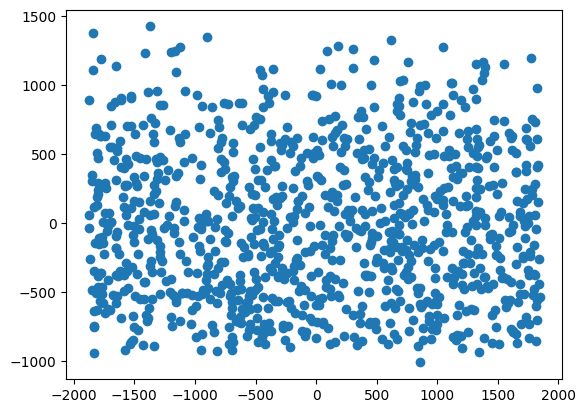

In [37]:
plt.scatter(
    PCADF[:,0],
    PCADF[:,1]
)

In [38]:
from sklearn.cluster import KMeans

In [39]:
wcss = []
for i in range(1,11):
    model = KMeans(n_clusters=i)
    model.fit(PCADF)
    wcss.append(model.inertia_)
wcss

[1473740294.2007143,
 585073511.8106225,
 423765119.93986094,
 332781058.48249733,
 267401836.64168084,
 226364333.03002,
 174887597.2624597,
 152936034.44473282,
 142857809.1460974,
 127798651.83050328]

([<matplotlib.axis.YTick at 0x1b1e3124da0>,
 [Text(0, 1473740294.2007143, '1.474'),
  Text(0, 585073511.8106225, '0.585'),
  Text(0, 423765119.93986094, '0.424'),
  Text(0, 332781058.48249733, '0.333'),
  Text(0, 267401836.64168084, '0.267'),
  Text(0, 226364333.03002, '0.226'),
  Text(0, 174887597.2624597, '0.175'),
  Text(0, 152936034.44473282, '0.153'),
  Text(0, 142857809.1460974, '0.143'),
  Text(0, 127798651.83050328, '0.128')])

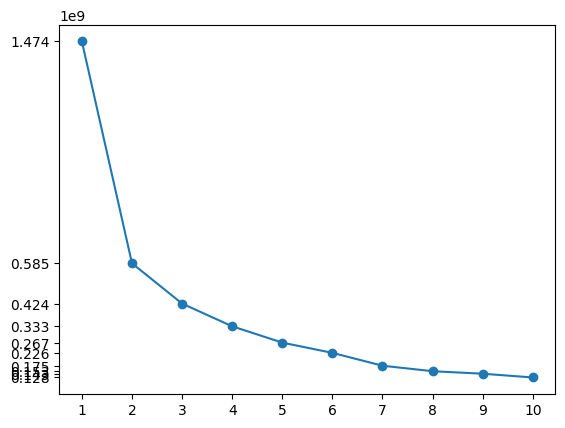

In [40]:
clusters = [1,2,3,4,5,6,7,8,9,10]
plt.plot(clusters,wcss,marker = 'o')
plt.xticks(clusters)
plt.yticks(wcss)

In [41]:
model = KMeans(n_clusters=2)
model.fit(PCADF)

KMeans(n_clusters=2)

In [42]:
df['Category'] = model.predict(PCADF)


In [43]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,Category
0,1043,1,1.8,1,14,0,5,0.1,193,3,...,226,1412,3476,12,7,2,0,1,0,1
1,841,1,0.5,1,4,1,61,0.8,191,5,...,746,857,3895,6,0,7,1,0,0,1
2,1807,1,2.8,0,1,0,27,0.9,186,3,...,1270,1366,2396,17,10,10,0,1,1,1
3,1546,0,0.5,1,18,1,25,0.5,96,8,...,295,1752,3893,10,0,7,1,1,0,1
4,1434,0,1.4,0,11,1,49,0.5,108,6,...,749,810,1773,15,8,7,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1700,1,1.9,0,0,1,54,0.5,170,7,...,644,913,2121,14,8,15,1,1,0,0
996,609,0,1.8,1,0,0,13,0.9,186,4,...,1152,1632,1933,8,1,19,0,1,1,0
997,1185,0,1.4,0,1,1,8,0.5,80,1,...,477,825,1223,5,0,14,1,0,0,0
998,1533,1,0.5,1,0,0,50,0.4,171,2,...,38,832,2509,15,11,6,0,1,0,1


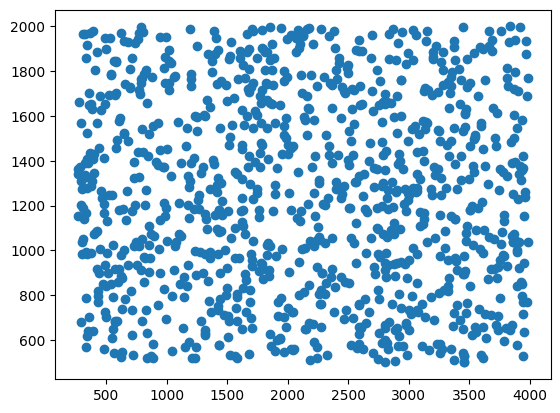

In [44]:
plt.scatter(df['ram'],df['battery_power'])

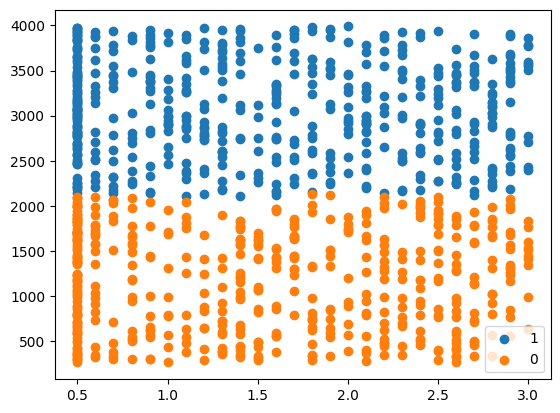

In [52]:
for i in df['Category'].unique():
    newDF = df[df['Category'] == i]
    plt.scatter(newDF['clock_speed'],newDF['ram'],label = i)
plt.legend()
plt.show()

In [46]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'Category'],
      dtype='object')

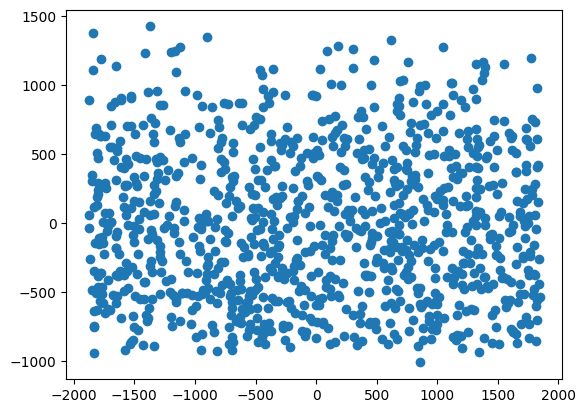

In [47]:
plt.scatter(PCADF[:,0],PCADF[:,1])

In [48]:
PCAPredict = []
for i in PCADF:
    PCAPredict.append([i[0],i[1],list(model.predict([i]))[0]])
PCAPredict

[[1333.0584544811263, -178.32657377582723, 1],
 [1767.7141590855322, -239.6126550467984, 1],
 [254.62816415944326, 606.7951331607333, 1],
 [1739.013992781137, 177.54067527194866, 1],
 [-362.29183329230705, -198.3237395901008, 0],
 [1366.240096763211, -223.33177942242355, 1],
 [1732.6385901791127, 612.9986418497601, 1],
 [-636.8524432580978, 873.1269010173392, 0],
 [1351.1295571503697, -322.9935621896957, 1],
 [-1495.8814319996918, -529.1621272049696, 0],
 [1720.0569930446613, 19.09691858664246, 1],
 [1760.421899409554, 52.08889586528085, 1],
 [-1699.525714692723, 555.4021384251762, 0],
 [-1157.7669189502726, 152.23389345184478, 0],
 [628.5554871057807, 455.0451168787936, 1],
 [-1596.9473643078109, 190.51392382209883, 0],
 [-70.55688061657997, 278.8426602717077, 0],
 [55.989023026837, -732.1109459513517, 1],
 [1750.1664304976093, 3.0273216021853386, 1],
 [382.3466915804388, -853.0806669265289, 1],
 [-787.0435810211152, 368.07272040226917, 0],
 [1322.2455331072006, 85.92456205097733, 1],

In [49]:
import numpy as np

In [50]:
PCAPredict = np.array(PCAPredict)

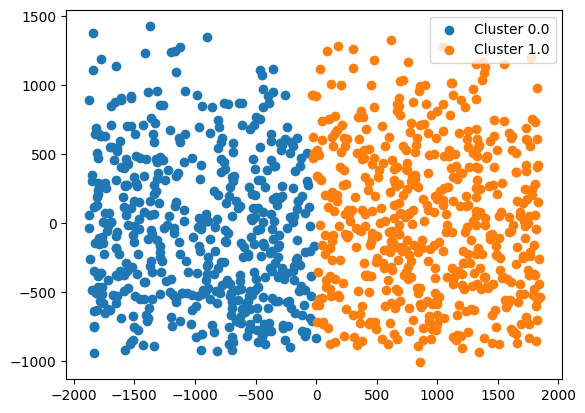

In [51]:
for cluster_id in np.unique(PCAPredict[:,2]):
    cluster_points = PCAPredict[PCAPredict[:,2] == cluster_id]
    plt.scatter(cluster_points[:,0], cluster_points[:,1], label=f"Cluster {cluster_id}")

plt.legend()
plt.show()